# Human in the Loop (Human Feedback)

In [1]:
# Loading the model

import os
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10b139af0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10b526480>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [2]:
# Importing necessary libraries

from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt # interrupt --> forcefully interupting the workflow for a human feedback 

/Users/soubhiksinha/GitHub/Agentic-AI-LangGraph-and-MCP/.venv/lib/python3.12/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
# Creating State Class

class State(TypedDict):
  messages: Annotated[list, add_messages]

In [4]:
graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
  """Request assistant froma human"""
  human_response = interrupt({"query" : query})
  return human_response["data"]

In [5]:
# Defining tools
tool = TavilySearch(max_results = 2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

In [6]:
# Defining chatbot function

def chatBot(state: State):
  message = llm_with_tools.invoke(state["messages"])
  # As we will be interrupting teh workflow during tool execution,
  # we disable parallel tool calling to avoid repeatation of any
  # tool invocations when we resume.

  return {"messages" : [message]}

In [7]:
# Building the graph

# Adding Nodes
graph_builder.add_node("chatBot", chatBot)
tool_node = ToolNode(tools = tools) # Interrupt will happen in tool node
graph_builder.add_node("tools", tool_node)
graph_builder.add_conditional_edges(
  "chatBot",
  tools_condition
)

# Adding Edges
graph_builder.add_edge("tools", "chatBot")
graph_builder.add_edge(START, "chatBot")


In [8]:
# Compiling the Graph

# Creating Memory object
memory = MemorySaver()

graph = graph_builder.compile(checkpointer = memory)

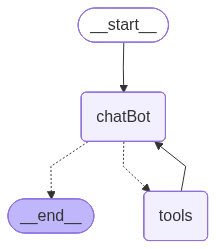

In [9]:
graph

In [12]:
# Invoking the graph (workflow)

user_input_1 = "I need some expert guidance & assistance for building an AI Agent. Could you request assistance for me ?"
config = {"configurable" : {"thread_id" : "1"}} # Setting thread_id for a session (for memory)

events = graph.stream(
  {
    "messages" : user_input_1
  },
  config,
  stream_mode = "values" # History will be preserved
)

for event in events:
  if "messages" in event:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance & assistance for building an AI Agent. Could you request assistance for me ?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (deh8m2nk0)
 Call ID: deh8m2nk0
  Args:
    query: Expert guidance building AI Agent, AI Agent development expert assistance
================================== Ai Message ==================================
Tool Calls:
  human_assistance (deh8m2nk0)
 Call ID: deh8m2nk0
  Args:
    query: Expert guidance building AI Agent, AI Agent development expert assistance


In [ ]:
# Human in the loop (Human Assistant)

human_response = (
  "We, the experts are here to help! We'd recommend you checkout LangGraph Documentation to build your agent."
  "It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume = {"data": human_response}) # For resuming the flow in the workflow

events = graph.stream(human_command, config, stream_mode = "values")

for event in events:
  if "messages" in event:
    event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (deh8m2nk0)
 Call ID: deh8m2nk0
  Args:
    query: Expert guidance building AI Agent, AI Agent development expert assistance
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you checkout LangGraph Documentation to build your agent.It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (t5gqkbrtr)
 Call ID: t5gqkbrtr
  Args:
    query: LangGraph documentation
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "LangGraph documentation", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://reference.langchain.com/p